In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph


class AgentState(TypedDict):
    query: str
    answer: str
    context: list   # 웹 검색의 결과는 Document가 아님.
    
    
graph_builder = StateGraph(AgentState)
    

In [3]:
from langchain_tavily import TavilySearch

tabily_search_tool = TavilySearch(
    max_results=3,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=True,
    include_images=True
    )

def web_search(state:AgentState) :
    query = state["query"]
    results = tabily_search_tool.invoke(query)
    return {'context': results}

In [ ]:
from langsmith import Client
from langchain_openai import ChatOpenAI

client = Client()
generate_prompt = client.pull_prompt("rlm/rag-prompt")
generate_llm = ChatOpenAI(model="gpt-4o", max_completion_tokens=100)

def web_generate(state:AgentState) :
    context = state["context"]
    query = state["query"]
    rag_chain = generate_prompt | generate_llm
    response = rag_chain.invoke({"context": context, "question": query})
    return {"answer": response}


In [5]:
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

basic_llm = ChatOpenAI(model="gpt-4o-mini")

def basic_generate(state:AgentState) :
    query = state["query"]
    basic_llm_chain = basic_llm | StrOutputParser()
    llm_response = basic_llm_chain.invoke(query)
    return {"answer": llm_response}

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal

class Route(BaseModel):
    target: Literal['vector_store', 'llm', 'web_search'] = Field(
        description="The target for the query to answer"
    )

router_system_prompt = """
    You are an expert at routing a user's question to 'vector_store', 'llm', or 'web_search'.
    'vector_store' contains information about income tax up to january 2026.
    if you think the question is simple enough use 'llm'
    if you think you need to search the web to answer the question use 'web_search'
"""

router_prompt = ChatPromptTemplate.from_messages([
    ("system", router_system_prompt),
    ("user", "{query}")
])

router_llm = ChatOpenAI(model="gpt-4o-mini")
structured_router_llm = router_llm.with_structured_output(Route)
                                        
def router(state:AgentState) -> Literal['vector_store', 'llm', 'web_search']:
    query = state['query']
    router_chain = router_prompt | structured_router_llm | StrOutputParser()
    route = router_chain.invoke({'query': query})
    return route.target

In [7]:
from income_tax_graph import graph as income_tax_subgraph

graph_builder.add_node('income_tax_agent', income_tax_subgraph)
graph_builder.add_node('web_search', web_search)
graph_builder.add_node('web_generate', web_generate)
graph_builder.add_node('basic_generate', basic_generate)

In [9]:
from langgraph.graph import END, START

graph_builder.add_conditional_edges(START,
                       router,
                       {
                           'vector_store': 'income_tax_agent',
                           'llm': 'basic_generate',
                           'web_search': 'web_search'
                       }
                       )
graph_builder.add_edge('web_search', 'web_generate')
graph_builder.add_edge('web_generate', END)
graph_builder.add_edge('basic_generate', END)
graph_builder.add_edge('income_tax_agent', END)

In [10]:
graph = graph_builder.compile()

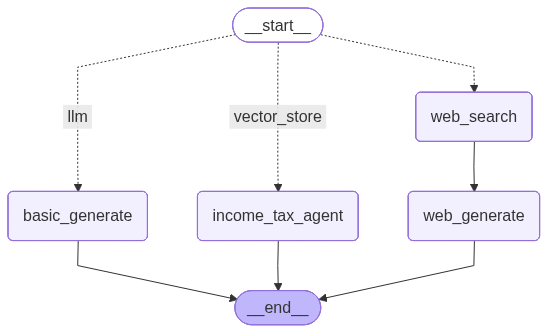

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))